In [7]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


In [8]:
descriptors_df_train = pd.read_pickle('data/descriptors_df_train_raw.pkl')
descriptors_df_test = pd.read_pickle('data/descriptors_netsim_5_full_raw.pkl')

#fill nans with mean
descriptors_df_train.fillna(descriptors_df_train.mean(), inplace=True)
descriptors_df_test.fillna(descriptors_df_test.mean(), inplace=True)

In [6]:
unique_graph_ids = descriptors_df_train['graph_id'].unique()
max_graphs = len(unique_graph_ids)
print(f"Total number of graphs: {max_graphs}")

# Define training set sizes (number of graphs)
# You can adjust these ranges based on your needs
training_sizes = [1,2,3,4,5,6,7,8,9,10,15,20,25,30,35,40,45,50,100, 200, 300, 500, 1000, 1500, 2000, 2500, 3000, 3240]


# Prepare test set
X_test = descriptors_df_test.drop(columns=['graph_id','edge_source','edge_dest','is_causal'])
y_test = descriptors_df_test['is_causal']

# Storage for results
results = []

# Set random seed for reproducibility
np.random.seed(42)

for size in training_sizes:
    print(f"Training with {size} graphs...", end=' ')
    
    # Randomly select subset of graph_ids
    selected_graph_ids = np.random.choice(unique_graph_ids, size=size, replace=False)
    
    # Filter training data to only include selected graphs
    train_subset = descriptors_df_train[descriptors_df_train['graph_id'].isin(selected_graph_ids)]
    
    # Prepare training data
    X_train = train_subset.drop(columns=['graph_id','edge_source','edge_dest','is_causal'])
    y_train = train_subset['is_causal']
    
    # Train model
    clf = BalancedRandomForestClassifier(
        n_estimators=500, 
        max_depth=None, 
        random_state=0, 
        sampling_strategy='auto',
        replacement=True,
        bootstrap=True,
        n_jobs=50
    )
    clf.fit(X_train, y_train)
    
    # Make predictions on test set
    y_pred_proba = clf.predict_proba(X_test)[:, 1]  # Get probability of positive class
    
    # Calculate ROC AUC
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    # Store results
    results.append({
        'training_graphs': size,
        'training_edges': len(train_subset),
        'roc_auc': roc_auc
    })
    
    print(f"  - ROC AUC: {roc_auc:.4f}")

# Convert results to DataFrame
results_df = pd.DataFrame(results)

Total number of graphs: 1000
Training with 1 graphs...   - ROC AUC: 0.7344
Training with 2 graphs...   - ROC AUC: 0.7631
Training with 3 graphs...   - ROC AUC: 0.7835
Training with 4 graphs...   - ROC AUC: 0.7680
Training with 5 graphs...   - ROC AUC: 0.7808
Training with 6 graphs...   - ROC AUC: 0.7980
Training with 7 graphs...   - ROC AUC: 0.8217
Training with 8 graphs...   - ROC AUC: 0.8427
Training with 9 graphs...   - ROC AUC: 0.8132
Training with 10 graphs...   - ROC AUC: 0.8018
Training with 15 graphs...   - ROC AUC: 0.8717
Training with 20 graphs...   - ROC AUC: 0.8205
Training with 25 graphs...   - ROC AUC: 0.8627
Training with 30 graphs...   - ROC AUC: 0.8586
Training with 35 graphs...   - ROC AUC: 0.8546
Training with 40 graphs...   - ROC AUC: 0.8657
Training with 45 graphs...   - ROC AUC: 0.8465
Training with 50 graphs...   - ROC AUC: 0.8635
Training with 100 graphs...   - ROC AUC: 0.8661
Training with 200 graphs...   - ROC AUC: 0.8536
Training with 300 graphs...   - ROC AU

ValueError: Cannot take a larger sample than population when 'replace=False'

Training model with full training set...
Average Precision Score: 0.6715
Baseline (random classifier): 0.1346


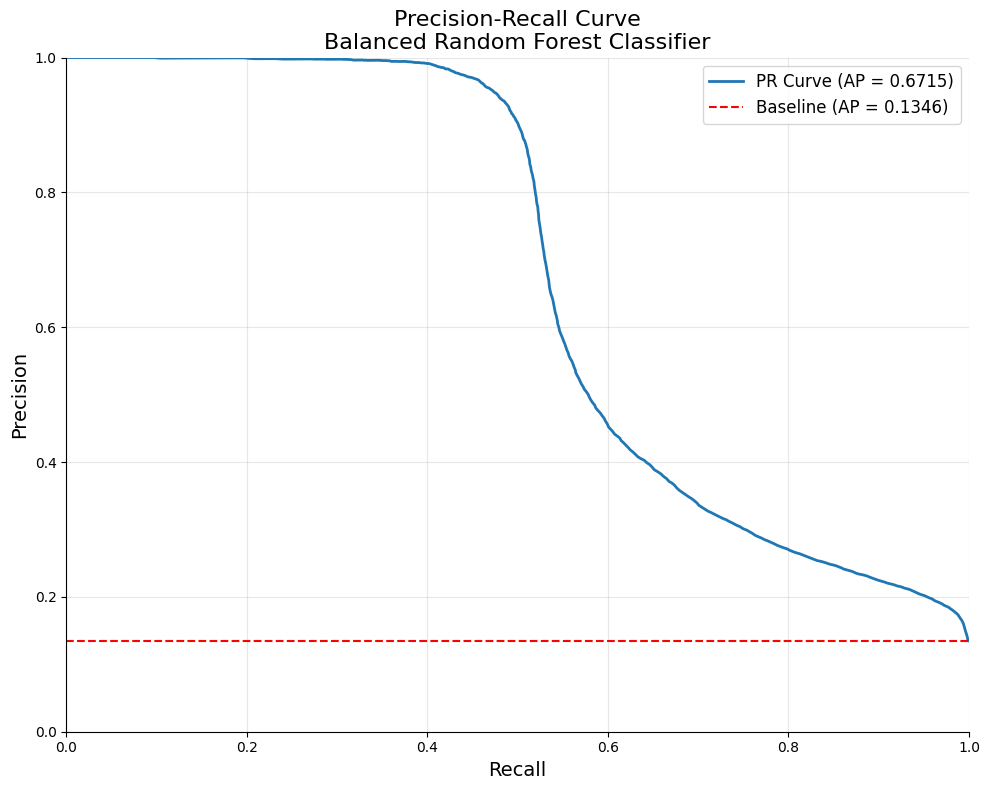


Model Performance Summary:
Training samples: 10,000
Test samples: 78,750
Positive class ratio in test set: 0.1346
Average Precision Score: 0.6715
Improvement over baseline: 4.99x


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.metrics import precision_recall_curve, average_precision_score
import seaborn as sns

# Load and prepare data
descriptors_df_train = pd.read_pickle('data/descriptors_df_train_raw.pkl')
descriptors_df_test = pd.read_pickle('data/descriptors_netsim_5_full_raw.pkl')

# Fill nans with mean
descriptors_df_train.fillna(descriptors_df_train.mean(), inplace=True)
descriptors_df_test.fillna(descriptors_df_test.mean(), inplace=True)

# Prepare training data (full dataset)
X_train = descriptors_df_train.drop(columns=['graph_id','edge_source','edge_dest','is_causal'])
y_train = descriptors_df_train['is_causal']

# Prepare test set
X_test = descriptors_df_test.drop(columns=['graph_id','edge_source','edge_dest','is_causal'])
y_test = descriptors_df_test['is_causal']

# Train model with full training set
print("Training model with full training set...")
clf = BalancedRandomForestClassifier(
    n_estimators=500, 
    max_depth=None, 
    random_state=0, 
    sampling_strategy='auto',
    replacement=True,
    bootstrap=True,
    n_jobs=50
)
clf.fit(X_train, y_train)

# Make predictions on test set
y_pred_proba = clf.predict_proba(X_test)[:, 1]  # Get probability of positive class

# Calculate precision-recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)

# Calculate average precision score (area under PR curve)
avg_precision = average_precision_score(y_test, y_pred_proba)

# Calculate baseline (random classifier performance)
baseline_precision = y_test.mean()

print(f"Average Precision Score: {avg_precision:.4f}")
print(f"Baseline (random classifier): {baseline_precision:.4f}")

# Create the PR curve plot
plt.figure(figsize=(10, 8))
plt.plot(recall, precision, linewidth=2, label=f'PR Curve (AP = {avg_precision:.4f})')
plt.axhline(y=baseline_precision, color='red', linestyle='--', 
           label=f'Baseline (AP = {baseline_precision:.4f})')

# Formatting
plt.xlabel('Recall', fontsize=14)
plt.ylabel('Precision', fontsize=14)
plt.title('Precision-Recall Curve\nBalanced Random Forest Classifier', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.xlim([0, 1])
plt.ylim([0, 1])

# Add some styling
plt.tight_layout()
sns.despine()

# Show plot
plt.show()

# Print some additional statistics
print(f"\nModel Performance Summary:")
print(f"Training samples: {len(X_train):,}")
print(f"Test samples: {len(X_test):,}")
print(f"Positive class ratio in test set: {y_test.mean():.4f}")
print(f"Average Precision Score: {avg_precision:.4f}")
print(f"Improvement over baseline: {avg_precision/baseline_precision:.2f}x")

In [10]:
import numpy as np
import pandas as pd
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.metrics import precision_recall_curve, average_precision_score

def print_pr_curve_textual(y_true, y_pred_proba, model_name="Model", num_points=20):
    """
    Print a textual representation of the PR curve that an LLM can easily understand
    """
    # Calculate precision-recall curve
    precision, recall, thresholds = precision_recall_curve(y_true, y_pred_proba)
    
    # Calculate average precision score
    avg_precision = average_precision_score(y_true, y_pred_proba)
    
    # Calculate baseline (random classifier performance)
    baseline_precision = y_true.mean()
    
    # Sample points evenly across recall range for textual representation
    recall_points = np.linspace(0, 1, num_points)
    precision_interpolated = np.interp(recall_points, recall[::-1], precision[::-1])
    
    print("=" * 80)
    print(f"PRECISION-RECALL CURVE ANALYSIS: {model_name}")
    print("=" * 80)
    
    # Summary statistics
    print(f"\n📊 PERFORMANCE SUMMARY:")
    print(f"   • Average Precision (AP) Score: {avg_precision:.4f}")
    print(f"   • Baseline (Random Classifier): {baseline_precision:.4f}")
    print(f"   • Improvement over Baseline: {avg_precision/baseline_precision:.2f}x")
    print(f"   • Total Test Samples: {len(y_true):,}")
    print(f"   • Positive Class Ratio: {y_true.mean():.4f} ({int(y_true.sum()):,} positive samples)")
    
    # Key thresholds analysis
    print(f"\n🎯 KEY OPERATING POINTS:")
    
    # Find some key operating points
    # High precision point (precision >= 0.9)
    high_prec_idx = np.where(precision >= 0.9)[0]
    if len(high_prec_idx) > 0:
        idx = high_prec_idx[0]
        print(f"   • High Precision Point: P={precision[idx]:.3f}, R={recall[idx]:.3f}, Threshold={thresholds[idx]:.3f}")
    
    # Balanced point (closest to F1 maximum)
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
    max_f1_idx = np.argmax(f1_scores)
    print(f"   • Best F1 Point: P={precision[max_f1_idx]:.3f}, R={recall[max_f1_idx]:.3f}, F1={f1_scores[max_f1_idx]:.3f}")
    
    # High recall point (recall >= 0.9)
    high_recall_idx = np.where(recall >= 0.9)[0]
    if len(high_recall_idx) > 0:
        idx = high_recall_idx[-1]  # Take the last one (highest precision among high recall)
        print(f"   • High Recall Point: P={precision[idx]:.3f}, R={recall[idx]:.3f}, Threshold={thresholds[idx]:.3f}")
    
    # ASCII Art PR Curve
    print(f"\n📈 PR CURVE VISUALIZATION (ASCII):")
    print("    Precision")
    print("    1.0 |")
    
    # Create ASCII representation
    for i in range(num_points):
        r = recall_points[i]
        p = precision_interpolated[i]
        
        # Create visual bar
        bar_length = int(p * 50)  # Scale to 50 chars
        bar = "█" * bar_length + "░" * (50 - bar_length)
        
        print(f"        |{bar}| P={p:.3f} @ R={r:.3f}")
    
    print("    0.0 |" + "─" * 52)
    print("        0.0" + " " * 44 + "1.0")
    print("        " + " " * 20 + "Recall")
    
    # Detailed numerical table
    print(f"\n📋 DETAILED PR CURVE DATA:")
    print("    Recall  | Precision | Threshold |   F1   | Samples@Threshold")
    print("    --------|-----------|-----------|--------|-----------------")
    
    # Show every 10th point for detail
    step = max(1, len(precision) // 15)  # Show ~15 points
    for i in range(0, len(precision), step):
        if i < len(thresholds):
            # Calculate how many samples would be classified as positive at this threshold
            samples_positive = (y_pred_proba >= thresholds[i]).sum()
            f1 = f1_scores[i] if i < len(f1_scores) else 0
            print(f"    {recall[i]:6.3f}  |  {precision[i]:7.3f}  |  {thresholds[i]:7.3f}  | {f1:6.3f} |     {samples_positive:,}")
    
    # Model interpretation guide
    print(f"\n🧠 INTERPRETATION GUIDE:")
    print("   • Average Precision (AP) summarizes the entire PR curve as a single number")
    print("   • Higher AP = better model performance across all operating points")
    print(f"   • Your model's AP of {avg_precision:.4f} vs baseline {baseline_precision:.4f}")
    
    if avg_precision > baseline_precision * 1.5:
        performance = "EXCELLENT"
    elif avg_precision > baseline_precision * 1.2:
        performance = "GOOD"
    elif avg_precision > baseline_precision * 1.1:
        performance = "MODERATE"
    else:
        performance = "POOR"
    
    print(f"   • Model Performance: {performance}")
    
    # Recommendations
    print(f"\n💡 RECOMMENDATIONS:")
    if avg_precision > 0.8:
        print("   • Model shows strong performance across precision-recall trade-offs")
        print("   • Consider deploying with confidence-based thresholding")
    elif avg_precision > 0.6:
        print("   • Model shows reasonable performance but may benefit from:")
        print("     - Feature engineering improvements")
        print("     - Hyperparameter tuning")
        print("     - Additional training data")
    else:
        print("   • Model performance is limited. Consider:")
        print("     - Reviewing feature selection and engineering")
        print("     - Trying different algorithms")
        print("     - Collecting more diverse training data")
        print("     - Addressing class imbalance more aggressively")
    
    print("=" * 80)

# Load and prepare data (same as your original code)
descriptors_df_train = pd.read_pickle('data/descriptors_df_train_raw.pkl')
descriptors_df_test = pd.read_pickle('data/descriptors_netsim_5_full_raw.pkl')

# Fill nans with mean
descriptors_df_train.fillna(descriptors_df_train.mean(), inplace=True)
descriptors_df_test.fillna(descriptors_df_test.mean(), inplace=True)

# Prepare training data (full dataset)
X_train = descriptors_df_train.drop(columns=['graph_id','edge_source','edge_dest','is_causal'])
y_train = descriptors_df_train['is_causal']

# Prepare test set
X_test = descriptors_df_test.drop(columns=['graph_id','edge_source','edge_dest','is_causal'])
y_test = descriptors_df_test['is_causal']

# Train model with full training set
print("Training model with full training set...")
clf = BalancedRandomForestClassifier(
    n_estimators=500, 
    max_depth=None, 
    random_state=0, 
    sampling_strategy='auto',
    replacement=True,
    bootstrap=True,
    n_jobs=50
)
clf.fit(X_train, y_train)

# Make predictions on test set
y_pred_proba = clf.predict_proba(X_test)[:, 1]

# Print the textual PR curve representation
print_pr_curve_textual(y_test, y_pred_proba, "Balanced Random Forest Classifier")

Training model with full training set...
PRECISION-RECALL CURVE ANALYSIS: Balanced Random Forest Classifier

📊 PERFORMANCE SUMMARY:
   • Average Precision (AP) Score: 0.6715
   • Baseline (Random Classifier): 0.1346
   • Improvement over Baseline: 4.99x
   • Total Test Samples: 78,750
   • Positive Class Ratio: 0.1346 (10,600 positive samples)

🎯 KEY OPERATING POINTS:
   • High Precision Point: P=0.901, R=0.501, Threshold=0.484
   • Best F1 Point: P=0.890, R=0.504, F1=0.644
   • High Recall Point: P=0.224, R=0.902, Threshold=0.100

📈 PR CURVE VISUALIZATION (ASCII):
    Precision
    1.0 |
        |██████████████████████████████████████████████████| P=1.000 @ R=0.000
        |██████████████████████████████████████████████████| P=1.000 @ R=0.053
        |█████████████████████████████████████████████████░| P=0.999 @ R=0.105
        |█████████████████████████████████████████████████░| P=0.999 @ R=0.158
        |█████████████████████████████████████████████████░| P=0.998 @ R=0.211
        |


Results Summary:
    training_graphs  training_edges   roc_auc
0                 1               3  0.692474
1                 2               6  0.773813
2                 3               9  0.834975
3                 4              12  0.883409
4                 5              15  0.924017
5                 6              18  0.841342
6                 7              21  0.902855
7                 8              24  0.909411
8                 9              27  0.934058
9                10              30  0.940028
10               15              45  0.858794
11               20              60  0.938325
12               25              75  0.949342
13               30              90  0.945136
14               35             105  0.959347
15               40             120  0.965436
16               45             135  0.965474
17               50             150  0.960626
18              100             300  0.968129
19              200             600  0.968929
20              

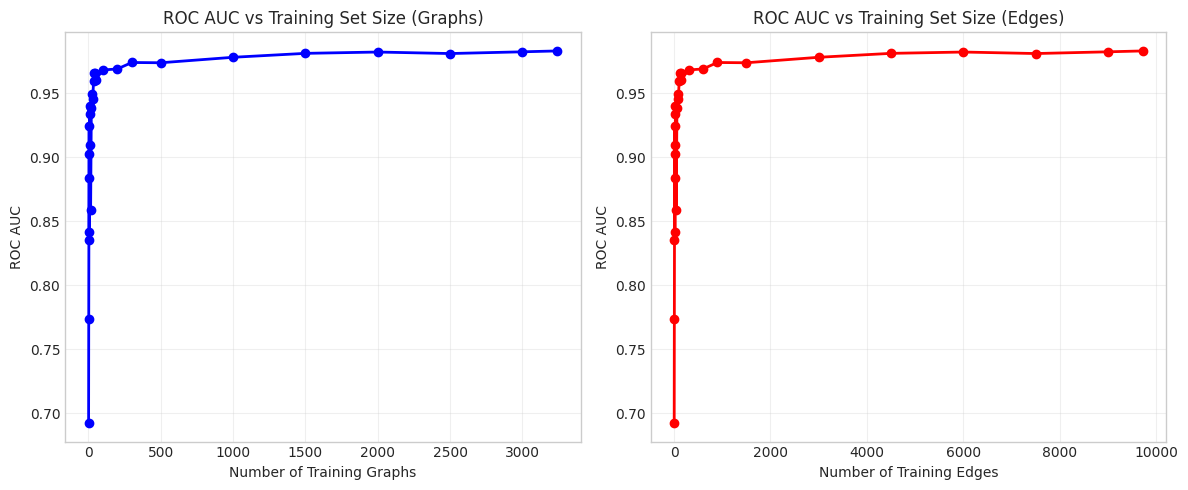


Results saved to 'training_size_analysis_results.csv'

Performance Statistics:
Best ROC AUC: 0.9830 (with 3240 graphs)
Worst ROC AUC: 0.6925 (with 1 graphs)
ROC AUC improvement: 0.2905


In [42]:
print("\nResults Summary:")
print(results_df)

# Plot results
plt.figure(figsize=(12, 5))

# Plot ROC AUC vs number of training graphs
plt.subplot(1, 2, 1)
plt.plot(results_df['training_graphs'], results_df['roc_auc'], 'b-o', linewidth=2, markersize=6)
plt.xlabel('Number of Training Graphs')
plt.ylabel('ROC AUC')
plt.title('ROC AUC vs Training Set Size (Graphs)')
plt.grid(True, alpha=0.3)

# Plot ROC AUC vs number of training edges
plt.subplot(1, 2, 2)
plt.plot(results_df['training_edges'], results_df['roc_auc'], 'r-o', linewidth=2, markersize=6)
plt.xlabel('Number of Training Edges')
plt.ylabel('ROC AUC')
plt.title('ROC AUC vs Training Set Size (Edges)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Save results
results_df.to_csv('training_size_analysis_results.csv', index=False)
print("\nResults saved to 'training_size_analysis_results.csv'")

# Print some statistics
print(f"\nPerformance Statistics:")
print(f"Best ROC AUC: {results_df['roc_auc'].max():.4f} (with {results_df.loc[results_df['roc_auc'].idxmax(), 'training_graphs']} graphs)")
print(f"Worst ROC AUC: {results_df['roc_auc'].min():.4f} (with {results_df.loc[results_df['roc_auc'].idxmin(), 'training_graphs']} graphs)")
print(f"ROC AUC improvement: {results_df['roc_auc'].max() - results_df['roc_auc'].min():.4f}")

In [43]:
# now on netsim